# CANS Risk Profile Analysis — Audit Notebook
### Aspiranet · Hope Forward · 2020–2025
---
**Purpose:** Reproduce every metric and chart shown in the dashboard so results
can be verified and audited. Every section prints the underlying numbers before
plotting, and Section 11 runs an explicit comparison against dashboard targets.

**Files required (same folder as this notebook):**
- `final_analysis_data.csv` — 1,062 rows, one per youth (first assessment only)
- `real_cleaned_data.csv` — 3,381 rows, all assessments per youth (trajectory only)

| Section | Content |
|---------|---------|
| 1 | Imports & style |
| 2 | Data loading |
| 3 | Preprocessing |
| 4 | Feature creation |
| 5 | Profile-level summaries |
| 6 | Finding 1 — Interaction effect |
| 7 | Finding 2 — Trajectories |
| 8 | Finding 3 — Multi-incident concentration |
| 9 | Incident-type summaries & heatmap |
| 10 | All dashboard charts |
| 11 | Validation checks against dashboard targets |

## Section 1 — Imports & Style

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Aspiranet palette (matches dashboard) ─────────────────────────────────
PROFILE_COLORS = {
    'Profile A': '#e05050',   # Behavioral + Risk
    'Profile B': '#e8a020',   # Functioning-Driven
    'Profile C': '#9060d8',   # High Acuity
    'Profile D': '#28b06a',   # Low Acuity
}
PROFILES = ['Profile A', 'Profile B', 'Profile C', 'Profile D']
TEAL = '#1bace4'

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.grid': True,
    'grid.alpha': 0.30,
    'grid.linestyle': '--',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})
print('Imports OK')

Imports OK


## Section 2 — Data Loading

> **`final_analysis_data.csv`** — primary dataset. One row per youth (first assessment only).
> All clustering, profile assignments, and incident outcomes are pre-computed here.
>
> **`real_cleaned_data.csv`** — longitudinal dataset. One row per assessment event per youth.
> Used only in Section 7 (trajectory analysis).
>
> Both files share `OptionsNumber` as the unique youth identifier.

In [2]:
df   = pd.read_csv('final_analysis_data.csv',
                   parse_dates=['DateCompleted', 'start', 'stop'])
full = pd.read_csv('real_cleaned_data.csv',
                   parse_dates=['DateCompleted'])

print(f'final_analysis_data : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'real_cleaned_data   : {full.shape[0]:,} rows x {full.shape[1]} columns')
print()
print('Profile distribution:')
print(df['profile'].value_counts().sort_index())
print()
print(f'Overall any-incident rate: {df["any_incident"].mean()*100:.2f}%')

final_analysis_data : 1,062 rows x 67 columns
real_cleaned_data   : 3,381 rows x 106 columns

Profile distribution:
profile
Profile A    162
Profile B    316
Profile C    215
Profile D    366
Name: count, dtype: int64

Overall any-incident rate: 30.41%


## Section 3 — Preprocessing

Column group definitions and incident column lists used throughout the notebook.

In [3]:
# ── CANS domain item lists ────────────────────────────────────────────────
BE_COLS = [
    'Psychosis', 'Impulsivity/Hyperactivity', 'Depression', 'Anxiety',
    'Oppositional', 'Conduct', 'Anger Control', 'Substance Use',
    'Adjustment To Trauma',
]
LF_COLS = [
    'Family Function', 'Living Situation', 'Social Functioning',
    'Developmental/Intellectual', 'Decision Making/Judgment', 'School Behavior',
    'School Achievement', 'School Attendance', 'Medical/Physical Health',
    'Sexual Development', 'Sleep',
]
RB_COLS = [
    'Suicide Risk', 'Non-Suicidal Self Injurious Behavior',
    'Other Self Harm (Recklessness)', 'Danger To Others', 'Sexual Aggression',
    'Delinquent Behavior', 'Runaway', 'Intentional Misbehavior/Social Behavior',
]

# ── Incident outcome columns (8 binary flags) ─────────────────────────────
INCIDENT_COLS = [
    'Abuse_CPS_Report_event',
    'Suicide_Related_Incidents_event',
    'AWOL_Child_Absense_event',
    'Behavioral_Incidents_event',
    'Health_Medical_Incidents_event',
    'Self_Harm_event',
    'Placement_Changes_event',
    'Police_Involvement_event',
]
INCIDENT_LABELS = {
    'Abuse_CPS_Report_event':          'Abuse / CPS Report',
    'Suicide_Related_Incidents_event': 'Suicide-Related',
    'AWOL_Child_Absense_event':        'AWOL / Absence',
    'Behavioral_Incidents_event':      'Behavioral',
    'Health_Medical_Incidents_event':  'Health / Medical',
    'Self_Harm_event':                 'Self-Harm',
    'Placement_Changes_event':         'Placement Changes',
    'Police_Involvement_event':        'Police Involvement',
}

# ── Verify required columns are present ───────────────────────────────────
required = ['profile', 'be_mean', 'lf_mean', 'rb_mean',
            'Depression', 'Suicide Risk', 'any_incident',
            'prior_abuse_flag'] + INCIDENT_COLS
missing = [c for c in required if c not in df.columns]
print('Missing columns:', missing if missing else 'None — all present')
print(f'Columns available: {df.shape[1]}')

Missing columns: None — all present
Columns available: 67


## Section 4 — Feature Creation

Derive the binary flags and count variables used in all three findings.

In [4]:
# ── Binary flags for Finding 1 (interaction effect) ─────────────────────
# Threshold: score >= 2 = 'actionable need' per CA IP-CANS protocol
df['depression_high']   = (df['Depression']   >= 2).astype(int)
df['suicide_risk_high'] = (df['Suicide Risk'] >= 2).astype(int)

print('depression_high  prevalence:', f"{df['depression_high'].mean()*100:.1f}%")
print('suicide_risk_high prevalence:', f"{df['suicide_risk_high'].mean()*100:.1f}%")

# ── Multi-incident count for Finding 3 ───────────────────────────────────
# Count how many DISTINCT incident types each youth experienced
df['incident_type_count'] = df[INCIDENT_COLS].sum(axis=1)

print()
print('Incident type count distribution:')
print(df['incident_type_count'].value_counts().sort_index())

# ── Assessment sequence for trajectory analysis ───────────────────────────
# Add to the longitudinal file; merge profile labels from first-assessment data
full = full.sort_values(['OptionsNumber', 'DateCompleted'])
full['assessment_n'] = full.groupby('OptionsNumber').cumcount() + 1
full = full.merge(df[['OptionsNumber', 'profile']], on='OptionsNumber', how='inner')

print()
print('Assessment sequence distribution (longitudinal file):')
print(full['assessment_n'].value_counts().sort_index().head(7))

depression_high  prevalence: 29.0%
suicide_risk_high prevalence: 11.0%

Incident type count distribution:
incident_type_count
0    739
1    239
2     65
3     17
4      2
Name: count, dtype: int64

Assessment sequence distribution (longitudinal file):
assessment_n
1    1062
2     839
3     556
4     378
5     219
6     133
7      73
Name: count, dtype: int64


## Section 5 — Profile-Level Summaries

These tables reproduce the values shown in the Overview tab profile cards.

In [5]:
# ── Profile sizes ────────────────────────────────────────────────────────
profile_sizes = df['profile'].value_counts().sort_index().rename('n')
print('PROFILE SIZES')
print(profile_sizes.to_frame())
print(f'Total: {profile_sizes.sum()}')

PROFILE SIZES
             n
profile       
Profile A  162
Profile B  316
Profile C  215
Profile D  366
Total: 1059


In [6]:
# ── Domain means by profile ──────────────────────────────────────────────
domain_means = df.groupby('profile')[['be_mean', 'lf_mean', 'rb_mean']].mean().round(4)
domain_means.columns = ['BE Mean', 'LF Mean', 'RB Mean']
print('DOMAIN MEANS BY PROFILE (0-3 scale)')
print(domain_means.to_string())

DOMAIN MEANS BY PROFILE (0-3 scale)
           BE Mean  LF Mean  RB Mean
profile                             
Profile A   1.5455   1.4036   1.0622
Profile B   1.0397   0.7579   0.5050
Profile C   1.0481   1.3174   0.3971
Profile D   0.5304   0.5406   0.1432


In [7]:
# ── Incident rates by profile ─────────────────────────────────────────────
# Denominator: all youth in each profile
# Numerator:   youth with any_incident = 1 in the observation window
inc_rates = (
    df.groupby('profile')['any_incident']
    .agg(['mean', 'sum', 'count'])
    .rename(columns={'mean':'rate','sum':'n_with_incident','count':'n_total'})
)
inc_rates['rate_pct'] = (inc_rates['rate'] * 100).round(4)
print('ANY-INCIDENT RATES BY PROFILE')
print(inc_rates[['n_total','n_with_incident','rate_pct']].to_string())

ANY-INCIDENT RATES BY PROFILE
           n_total  n_with_incident  rate_pct
profile                                      
Profile A      162               70   43.2099
Profile B      316              110   34.8101
Profile C      215               75   34.8837
Profile D      366               67   18.3060


In [8]:
# ── Full summary table ────────────────────────────────────────────────────
summary = df.groupby('profile').agg(
    n=('OptionsNumber', 'size'),
    avg_age=('AgeWhenAssessed', 'mean'),
    be_mean=('be_mean', 'mean'),
    lf_mean=('lf_mean', 'mean'),
    rb_mean=('rb_mean', 'mean'),
    any_incident_rate=('any_incident', 'mean'),
    prior_abuse_pct=('prior_abuse_flag', 'mean'),
).round(4)
summary['any_incident_pct'] = (summary['any_incident_rate'] * 100).round(2)
summary['prior_abuse_pct']  = (summary['prior_abuse_pct']  * 100).round(1)
print('FULL PROFILE SUMMARY')
summary

FULL PROFILE SUMMARY


,n,avg_age,be_mean,lf_mean,rb_mean,any_incident_rate,prior_abuse_pct,any_incident_pct
profile,,,,,,,,
Profile A,162,13.6481,1.5455,1.4036,1.0622,0.4321,13.6,43.21
Profile B,316,12.8734,1.0397,0.7579,0.5050,0.3481,9.5,34.81
Profile C,215,13.3860,1.0481,1.3174,0.3971,0.3488,7.0,34.88
Profile D,366,12.2158,0.5304,0.5406,0.1432,0.1831,3.0,18.31


## Section 6 — Finding 1: Interaction Effect (Depression × Suicide Risk)

**Question:** When Depression and Suicide Risk are both elevated (>=2), is the
incident rate higher than an additive model would predict?

**Groups:** Four mutually exclusive combinations of two binary flags.

**Additive prediction** for group 11 = `rate_10 + rate_01 - rate_00`.
This is what we'd expect if the two risks simply stacked linearly.
Any excess above this is evidence of a synergistic / multiplicative effect.

In [9]:
# ── Build the 4 groups ───────────────────────────────────────────────────
g00 = df[(df['depression_high']==0) & (df['suicide_risk_high']==0)]
g10 = df[(df['depression_high']==1) & (df['suicide_risk_high']==0)]
g01 = df[(df['depression_high']==0) & (df['suicide_risk_high']==1)]
g11 = df[(df['depression_high']==1) & (df['suicide_risk_high']==1)]

r00 = g00['any_incident'].mean()
r10 = g10['any_incident'].mean()
r01 = g01['any_incident'].mean()
r11 = g11['any_incident'].mean()

additive_pred = r10 + r01 - r00
excess        = r11 - additive_pred
ratio         = r11 / additive_pred

interaction_df = pd.DataFrame({
    'Group':       ['Neither (00)', 'Depression Only (10)',
                    'SR Only (01)', 'Both Elevated (11)'],
    'n':           [len(g00), len(g10), len(g01), len(g11)],
    'n_incident':  [g00['any_incident'].sum(), g10['any_incident'].sum(),
                    g01['any_incident'].sum(), g11['any_incident'].sum()],
    'rate_pct':    [r00*100, r10*100, r01*100, r11*100],
})
print('INTERACTION EFFECT — ANY-INCIDENT RATES')
print(interaction_df.to_string(index=False))
print()
print(f'Additive prediction for Both Elevated: {additive_pred*100:.4f}%')
print(f'Actual Both Elevated rate:             {r11*100:.4f}%')
print(f'Excess above additive:                 {excess*100:+.4f} pp')
print(f'Ratio (actual / additive):             {ratio:.4f}x')

# ── Statistical test ──────────────────────────────────────────────────────
ct = pd.DataFrame({
    'g00': g00['any_incident'].value_counts().reindex([0,1], fill_value=0),
    'g10': g10['any_incident'].value_counts().reindex([0,1], fill_value=0),
    'g01': g01['any_incident'].value_counts().reindex([0,1], fill_value=0),
    'g11': g11['any_incident'].value_counts().reindex([0,1], fill_value=0),
})
chi2, pval, dof, _ = stats.chi2_contingency(ct.values)
print(f'Chi-square: chi2={chi2:.2f}  df={dof}  p={pval:.6f}')

INTERACTION EFFECT — ANY-INCIDENT RATES
               Group   n  n_incident  rate_pct
        Neither (00) 721         182 25.242718
Depression Only (10) 224          81 36.160714
        SR Only (01)  33           9 27.272727
  Both Elevated (11)  84          51 60.714286

Additive prediction for Both Elevated: 38.1907%
Actual Both Elevated rate:             60.7143%
Excess above additive:                 +22.5236 pp
Ratio (actual / additive):             1.5898x
Chi-square: chi2=49.20  df=3  p=0.000000


## Section 7 — Finding 2: Score Trajectories Across Assessments

**Question:** Do CANS scores improve or worsen across assessment cycles by profile?

**Source:** `real_cleaned_data.csv` (all assessments). Profile labels merged from
`final_analysis_data.csv` and fixed at intake — youth do not change profile over time.

**Key result:** Profile A (Suicide Risk 1.09 at intake) declines to 0.55 by A5.
Profile C (0.43 at intake) rises to 0.59 by A5 — quietly escalating while in care.

In [10]:
# ── Trajectory computation ────────────────────────────────────────────────
TRAJ_ITEMS = ['Suicide Risk', 'Depression', 'Adjustment To Trauma', 'Danger To Others']
MAX_N      = 5   # only plot up to 5th assessment (sufficient sample size)

def get_trajectory(item, max_n=MAX_N):
    rows = []
    for p in PROFILES:
        for n in range(1, max_n+1):
            sub = full[(full['profile']==p) & (full['assessment_n']==n)][item].dropna()
            rows.append({'Profile':p, 'Assessment':n,
                         'mean': sub.mean() if len(sub)>5 else np.nan,
                         'n': len(sub)})
    return pd.DataFrame(rows)

sr_traj = get_trajectory('Suicide Risk')
print('SUICIDE RISK TRAJECTORY (mean by profile and assessment)')
print(sr_traj.pivot(index='Profile', columns='Assessment', values='mean').round(4).to_string())

SUICIDE RISK TRAJECTORY (mean by profile and assessment)
Assessment       1       2       3       4       5
Profile                                           
Profile A   1.0875  0.9576  0.9254  0.7619  0.5517
Profile B   0.6134  0.6148  0.5238  0.5982  0.5312
Profile C   0.4326  0.4651  0.5478  0.5556  0.5918
Profile D   0.2210  0.2431  0.2808  0.2286  0.2667


In [11]:
# ── Trend test: is the change over assessments significant? ──────────────
print('PEARSON r TREND TEST — Suicide Risk vs Assessment Number')
print(f'{"Profile":<12}  {"r":>8}  {"p-value":>10}  Direction')
print('-' * 50)
for p in PROFILES:
    sub = full[(full['profile']==p) & (full['assessment_n']<=MAX_N)]
    sub = sub[['assessment_n', 'Suicide Risk']].dropna()
    r, pv = stats.pearsonr(sub['assessment_n'], sub['Suicide Risk'])
    direction = 'escalating' if r > 0 else 'improving'
    sig = ' *' if pv < .05 else (' (trend)' if pv < .10 else '')
    print(f'  {p:<12}  r={r:+.4f}  p={pv:.4f}  {direction}{sig}')

PEARSON r TREND TEST — Suicide Risk vs Assessment Number
Profile              r     p-value  Direction
--------------------------------------------------
  Profile A     r=-0.1708  p=0.0005  improving *
  Profile B     r=-0.0324  p=0.3278  improving
  Profile C     r=+0.0772  p=0.0525  escalating (trend)
  Profile D     r=+0.0253  p=0.4086  escalating


In [12]:
# ── Full trajectory table for all 4 items ────────────────────────────────
print('FULL TRAJECTORY TABLE (mean scores by profile and assessment)')
for item in TRAJ_ITEMS:
    t = get_trajectory(item)
    pivot = t.pivot(index='Profile', columns='Assessment', values='mean').round(4)
    print(f'\n{item}:')
    print(pivot.to_string())

FULL TRAJECTORY TABLE (mean scores by profile and assessment)

Suicide Risk:
Assessment       1       2       3       4       5
Profile                                           
Profile A   1.0875  0.9576  0.9254  0.7619  0.5517
Profile B   0.6134  0.6148  0.5238  0.5982  0.5312
Profile C   0.4326  0.4651  0.5478  0.5556  0.5918
Profile D   0.2210  0.2431  0.2808  0.2286  0.2667

Depression:
Assessment       1       2       3       4       5
Profile                                           
Profile A   1.5494  1.5603  1.5588  1.4524  1.3103
Profile B   1.1646  1.0579  1.0828  1.1062  1.0625
Profile C   1.0326  1.0000  1.0348  1.0122  1.0612
Profile D   0.5069  0.5000  0.5245  0.5177  0.5789

Adjustment To Trauma:
Assessment       1       2       3       4       5
Profile                                           
Profile A   2.0123  1.9153  1.7794  1.7143  1.6897
Profile B   1.4810  1.4170  1.3964  1.3982  1.3750
Profile C   1.3395  1.3563  1.3274  1.3049  1.2245
Profile D   0.8736  

## Section 8 — Finding 3: Multi-Incident Concentration

**Definition:** A youth is 'multi-incident' if `incident_type_count >= 2` —
they experienced two or more *distinct* incident types in their window.
This measures breadth of incident types, not frequency within a type.

**Key result:** 84 youth (7.9%) are multi-incident. Of these, 44% belong to
Profile B (Functioning-Driven), despite moderate intake scores.

In [13]:
# ── Multi-incident subgroup ───────────────────────────────────────────────
multi  = df[df['incident_type_count'] >= 2]
single = df[df['incident_type_count'] == 1]
none_  = df[df['incident_type_count'] == 0]

print(f'Youth with 0 incident types : {len(none_):>4}  ({len(none_)/len(df)*100:.1f}%)')
print(f'Youth with 1 incident type  : {len(single):>4}  ({len(single)/len(df)*100:.1f}%)')
print(f'Youth with 2+ incident types: {len(multi):>4}  ({len(multi)/len(df)*100:.1f}%)')
print()

# ── Multi-incident breakdown by profile ───────────────────────────────────
multi_summary = []
for p in PROFILES:
    pm = multi[multi['profile'] == p]
    pp = df[df['profile'] == p]
    multi_summary.append({
        'Profile':          p,
        'n_multi':          len(pm),
        'pct_of_multi':     round(len(pm) / len(multi) * 100, 1),
        'pct_of_profile':   round(len(pm) / len(pp)   * 100, 1),
    })

multi_df = pd.DataFrame(multi_summary).set_index('Profile')
print('MULTI-INCIDENT SUBGROUP BY PROFILE')
print(multi_df.to_string())

Youth with 0 incident types :  739  (69.6%)
Youth with 1 incident type  :  239  (22.5%)
Youth with 2+ incident types:   84  (7.9%)

MULTI-INCIDENT SUBGROUP BY PROFILE
           n_multi  pct_of_multi  pct_of_profile
Profile                                         
Profile A       17          20.2            10.5
Profile B       37          44.0            11.7
Profile C       18          21.4             8.4
Profile D       12          14.3             3.3


## Section 9 — Incident-Type Summaries & Heatmap Data

Per-profile rates for each of the 8 incident types. These are the values
shown in the dashboard heatmap.

In [14]:
# ── Heatmap data table ───────────────────────────────────────────────────
heat_rows = {}
for col in INCIDENT_COLS:
    label = INCIDENT_LABELS[col]
    heat_rows[label] = {
        p: round(df[df['profile']==p][col].mean()*100, 2)
        for p in PROFILES
    }

heat_df = pd.DataFrame(heat_rows).T
heat_df.index.name = 'Incident Type'
print('INCIDENT TYPE RATES BY PROFILE (%)')
print(heat_df.to_string())

INCIDENT TYPE RATES BY PROFILE (%)
                    Profile A  Profile B  Profile C  Profile D
Incident Type                                                 
Abuse / CPS Report      15.43      10.76      13.95       5.74
Suicide-Related          8.02       8.86       8.37       4.92
AWOL / Absence           7.41       5.38       7.91       2.19
Behavioral               4.94       5.70       5.12       2.19
Health / Medical         4.94       6.96       5.58       4.37
Self-Harm                3.09       2.53       1.40       0.55
Placement Changes        1.85       2.22       0.47       1.09
Police Involvement      10.49       6.65       4.19       0.82


In [15]:
# ── Police vs Self-Harm (acuity paradox) ─────────────────────────────────
print('POLICE vs SELF-HARM RATE COMPARISON')
print(f'{"Profile":<12}  {"Police":>10}  {"Self-Harm":>12}')
for p in PROFILES:
    sub  = df[df['profile']==p]
    pol  = sub['Police_Involvement_event'].mean()*100
    sh   = sub['Self_Harm_event'].mean()*100
    print(f'  {p:<12}  {pol:>8.2f}%  {sh:>10.2f}%')

# Ratio: Profile A police / Profile C police
pa_pol = df[df['profile']=='Profile A']['Police_Involvement_event'].mean()*100
pc_pol = df[df['profile']=='Profile C']['Police_Involvement_event'].mean()*100
print(f'\nProfile A / Profile C police ratio: {pa_pol/pc_pol:.2f}x')

POLICE vs SELF-HARM RATE COMPARISON
Profile           Police     Self-Harm
  Profile A        10.49%        3.09%
  Profile B         6.65%        2.53%
  Profile C         4.19%        1.40%
  Profile D         0.82%        0.55%

Profile A / Profile C police ratio: 2.51x


## Section 10 — Dashboard Charts

All charts use the same Aspiranet color palette as the HTML dashboard.
Each chart is preceded by the underlying data table it is based on.

### 10a · Profile Size — Horizontal Bar (sorted descending)

  Profile   n
Profile D 366
Profile B 316
Profile C 215
Profile A 162



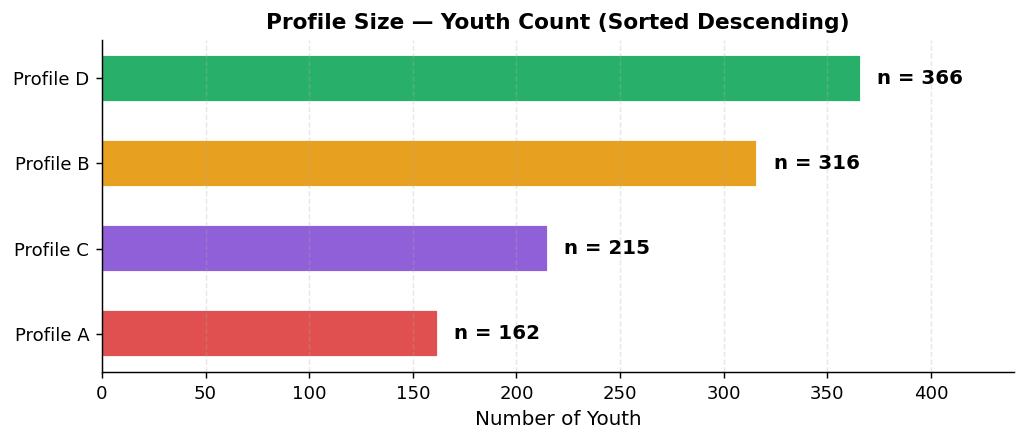

In [16]:
size_order  = df['profile'].value_counts().sort_values(ascending=False).reset_index()
size_order.columns = ['Profile', 'n']
print(size_order.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(
    size_order['Profile'],
    size_order['n'],
    color=[PROFILE_COLORS[p] for p in size_order['Profile']],
    height=0.55, edgecolor='white'
)
ax.set_xlabel('Number of Youth')
ax.set_title('Profile Size — Youth Count (Sorted Descending)')
ax.set_xlim(0, 440)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', alpha=0)
for bar, (_, row) in zip(bars, size_order.iterrows()):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'n = {row["n"]}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_profile_size.png', dpi=150, bbox_inches='tight')
plt.show()

### 10b · Any-Incident Rate by Profile

  Profile     Rate%
Profile A 43.209877
Profile B 34.810127
Profile C 34.883721
Profile D 18.306011



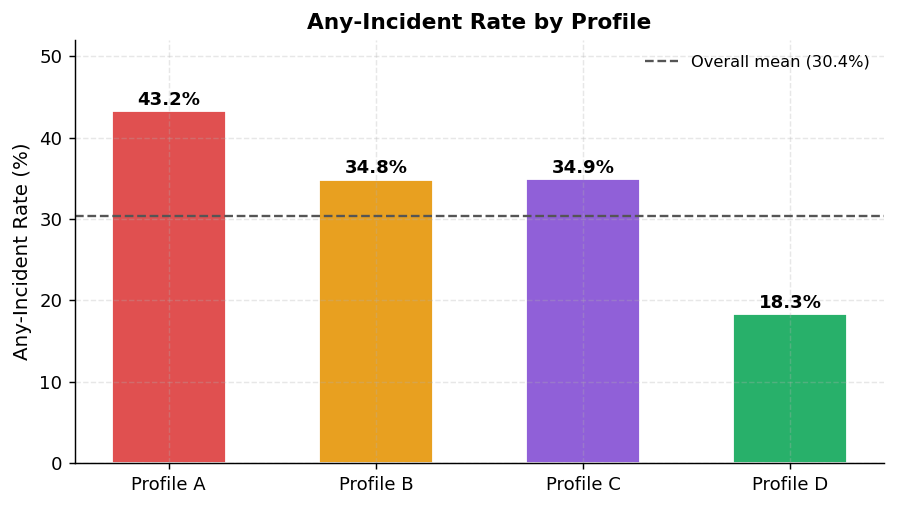

In [17]:
rates = [(p, df[df['profile']==p]['any_incident'].mean()*100) for p in PROFILES]
rate_df = pd.DataFrame(rates, columns=['Profile','Rate%'])
print(rate_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    rate_df['Profile'], rate_df['Rate%'],
    color=[PROFILE_COLORS[p] for p in PROFILES],
    width=0.55, edgecolor='white'
)
overall = df['any_incident'].mean()*100
ax.axhline(overall, color='#555', linestyle='--', linewidth=1.3,
           label=f'Overall mean ({overall:.1f}%)')
ax.set_ylabel('Any-Incident Rate (%)')
ax.set_title('Any-Incident Rate by Profile')
ax.set_ylim(0, 52)
ax.legend(frameon=False, fontsize=9)
for bar, (_, row) in zip(bars, rate_df.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{row['Rate%']:.1f}%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_incident_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### 10c · Domain Scores — Grouped Bar Chart

DOMAIN MEANS:
           be_mean  lf_mean  rb_mean
profile                             
Profile A   1.5455   1.4036   1.0622
Profile B   1.0397   0.7579   0.5050
Profile C   1.0481   1.3174   0.3971
Profile D   0.5304   0.5406   0.1432



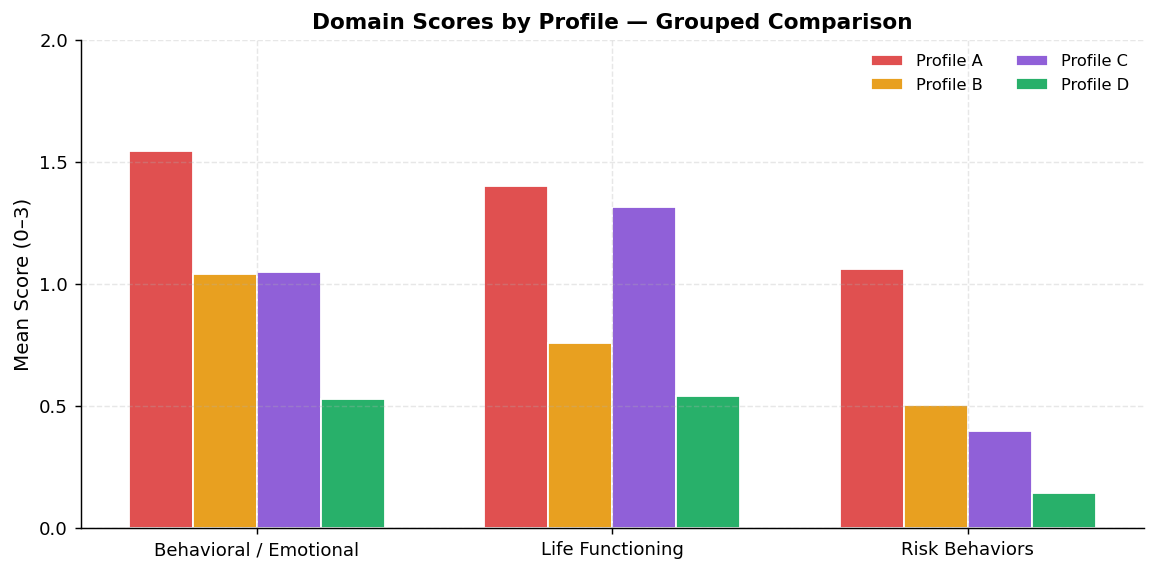

In [18]:
dom_data = df.groupby('profile')[['be_mean','lf_mean','rb_mean']].mean()
print('DOMAIN MEANS:')
print(dom_data.round(4).to_string())
print()

fig, ax = plt.subplots(figsize=(9, 4.5))
x     = np.arange(3)
width = 0.18
domain_labels = ['Behavioral / Emotional', 'Life Functioning', 'Risk Behaviors']

for i, p in enumerate(PROFILES):
    vals = dom_data.loc[p, ['be_mean','lf_mean','rb_mean']].values
    bars = ax.bar(x + (i-1.5)*width, vals, width=width,
                 label=p, color=PROFILE_COLORS[p], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(domain_labels)
ax.set_ylabel('Mean Score (0–3)')
ax.set_title('Domain Scores by Profile — Grouped Comparison')
ax.set_ylim(0, 2.0)
ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])
ax.legend(frameon=False, fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('fig_domain_scores.png', dpi=150, bbox_inches='tight')
plt.show()

### 10d · Finding 1 — Interaction Effect Chart

               Group   n  n_incident  rate_pct
        Neither (00) 721         182 25.242718
Depression Only (10) 224          81 36.160714
        SR Only (01)  33           9 27.272727
  Both Elevated (11)  84          51 60.714286
Additive prediction: 38.19%



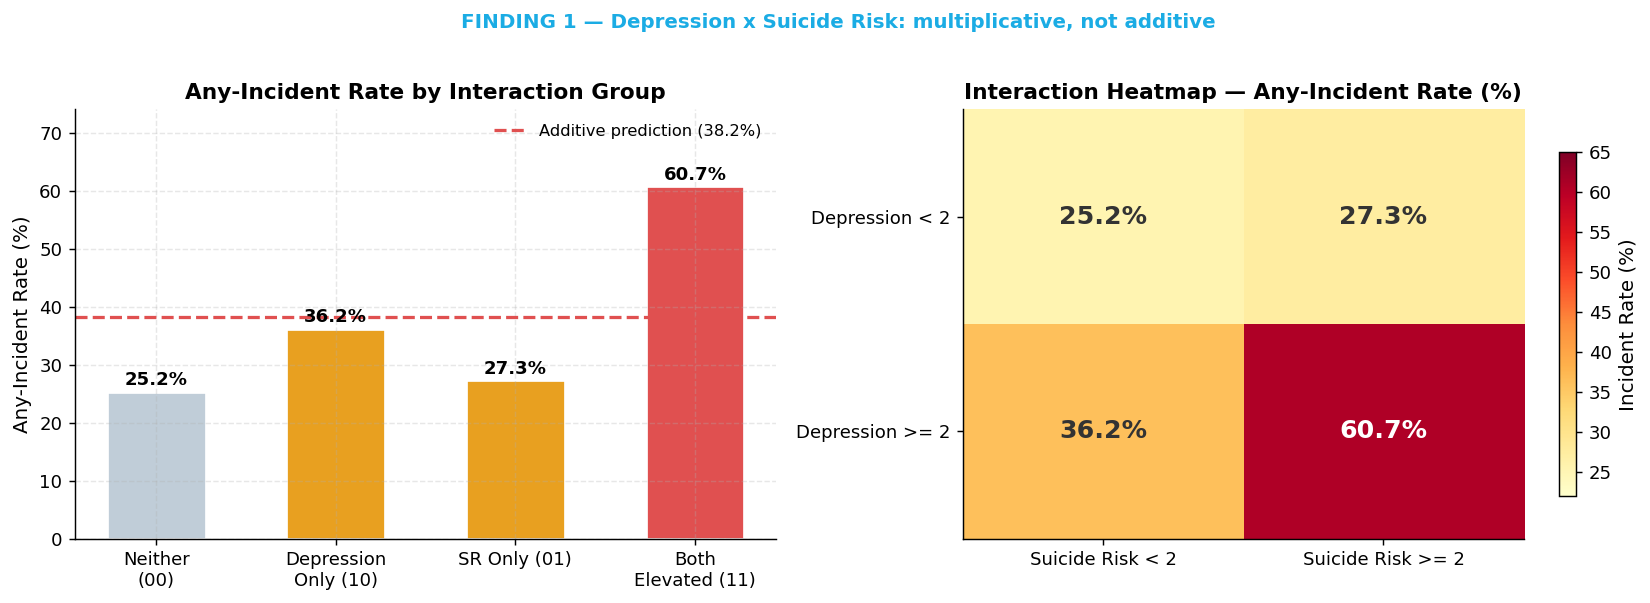

In [19]:
print(interaction_df.to_string(index=False))
print(f'Additive prediction: {additive_pred*100:.2f}%')
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart with additive line
ax = axes[0]
group_labels  = ['Neither\n(00)', 'Depression\nOnly (10)',
                  'SR Only (01)', 'Both\nElevated (11)']
group_rates   = [r00*100, r10*100, r01*100, r11*100]
bar_colors    = ['#c0cdd8', '#e8a020', '#e8a020', '#e05050']

bars = ax.bar(group_labels, group_rates, color=bar_colors,
              width=0.55, edgecolor='white', linewidth=1.5)
ax.axhline(additive_pred*100, color='#e05050', linestyle='--',
           linewidth=1.8, label=f'Additive prediction ({additive_pred*100:.1f}%)')
ax.set_title('Any-Incident Rate by Interaction Group')
ax.set_ylabel('Any-Incident Rate (%)')
ax.set_ylim(0, 74)
ax.legend(frameon=False, fontsize=9)
for bar, rate in zip(bars, group_rates):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2,
            f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Right: 2x2 heatmap grid
ax = axes[1]
matrix = np.array([
    [r00*100, r01*100],
    [r10*100, r11*100],
]) 
im = ax.imshow(matrix, cmap='YlOrRd', vmin=22, vmax=65, aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Suicide Risk < 2', 'Suicide Risk >= 2'])
ax.set_yticklabels(['Depression < 2', 'Depression >= 2'])
ax.set_title('Interaction Heatmap — Any-Incident Rate (%)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{matrix[i,j]:.1f}%', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if matrix[i,j] > 45 else '#333')
plt.colorbar(im, ax=ax, shrink=0.8, label='Incident Rate (%)')
ax.grid(False)
plt.suptitle('FINDING 1 — Depression x Suicide Risk: multiplicative, not additive',
             fontsize=11, fontweight='bold', y=1.02, color=TEAL)
plt.tight_layout()
plt.savefig('fig_finding1.png', dpi=150, bbox_inches='tight')
plt.show()

### 10e · Finding 2 — Suicide Risk Trajectory

SUICIDE RISK MEANS BY PROFILE AND ASSESSMENT:
Assessment       1       2       3       4       5
Profile                                           
Profile A   1.0875  0.9576  0.9254  0.7619  0.5517
Profile B   0.6134  0.6148  0.5238  0.5982  0.5312
Profile C   0.4326  0.4651  0.5478  0.5556  0.5918
Profile D   0.2210  0.2431  0.2808  0.2286  0.2667



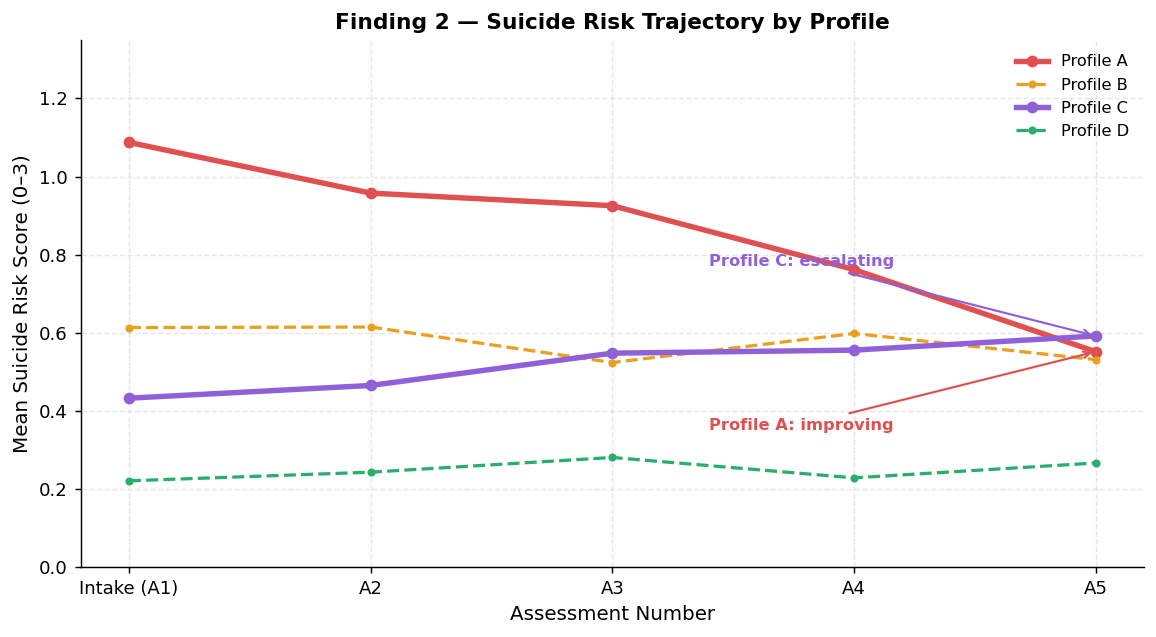

In [20]:
sr_pivot = sr_traj.pivot(index='Profile', columns='Assessment', values='mean').round(4)
print('SUICIDE RISK MEANS BY PROFILE AND ASSESSMENT:')
print(sr_pivot.to_string())
print()

fig, ax = plt.subplots(figsize=(9, 5))
assess_labels = ['Intake (A1)', 'A2', 'A3', 'A4', 'A5']

for p in PROFILES:
    vals = sr_traj[sr_traj['Profile']==p].sort_values('Assessment')['mean'].values
    is_key = p in ['Profile A', 'Profile C']
    ax.plot(
        range(1, MAX_N+1), vals,
        marker='o', linewidth=3 if is_key else 1.8,
        markersize=5.5 if is_key else 3.5,
        linestyle='-' if is_key else '--',
        label=p, color=PROFILE_COLORS[p]
    )

ax.set_xticks(range(1, MAX_N+1))
ax.set_xticklabels(assess_labels)
ax.set_xlabel('Assessment Number')
ax.set_ylabel('Mean Suicide Risk Score (0–3)')
ax.set_title('Finding 2 — Suicide Risk Trajectory by Profile')
ax.set_ylim(0, 1.35)
ax.legend(frameon=False, fontsize=9)

# Annotations for key profiles
ax.annotate('Profile C: escalating', color=PROFILE_COLORS['Profile C'],
            xy=(5, sr_pivot.loc['Profile C', 5]),
            xytext=(3.4, sr_pivot.loc['Profile C', 5]+0.18),
            fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=PROFILE_COLORS['Profile C'], lw=1.2))
ax.annotate('Profile A: improving', color=PROFILE_COLORS['Profile A'],
            xy=(5, sr_pivot.loc['Profile A', 5]),
            xytext=(3.4, sr_pivot.loc['Profile A', 5]-0.20),
            fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=PROFILE_COLORS['Profile A'], lw=1.2))
plt.tight_layout()
plt.savefig('fig_finding2.png', dpi=150, bbox_inches='tight')
plt.show()

### 10f · Finding 3 — Multi-Incident Concentration

  Profile  n_multi  pct_of_multi  pct_of_profile
Profile B       37          44.0            11.7
Profile C       18          21.4             8.4
Profile A       17          20.2            10.5
Profile D       12          14.3             3.3



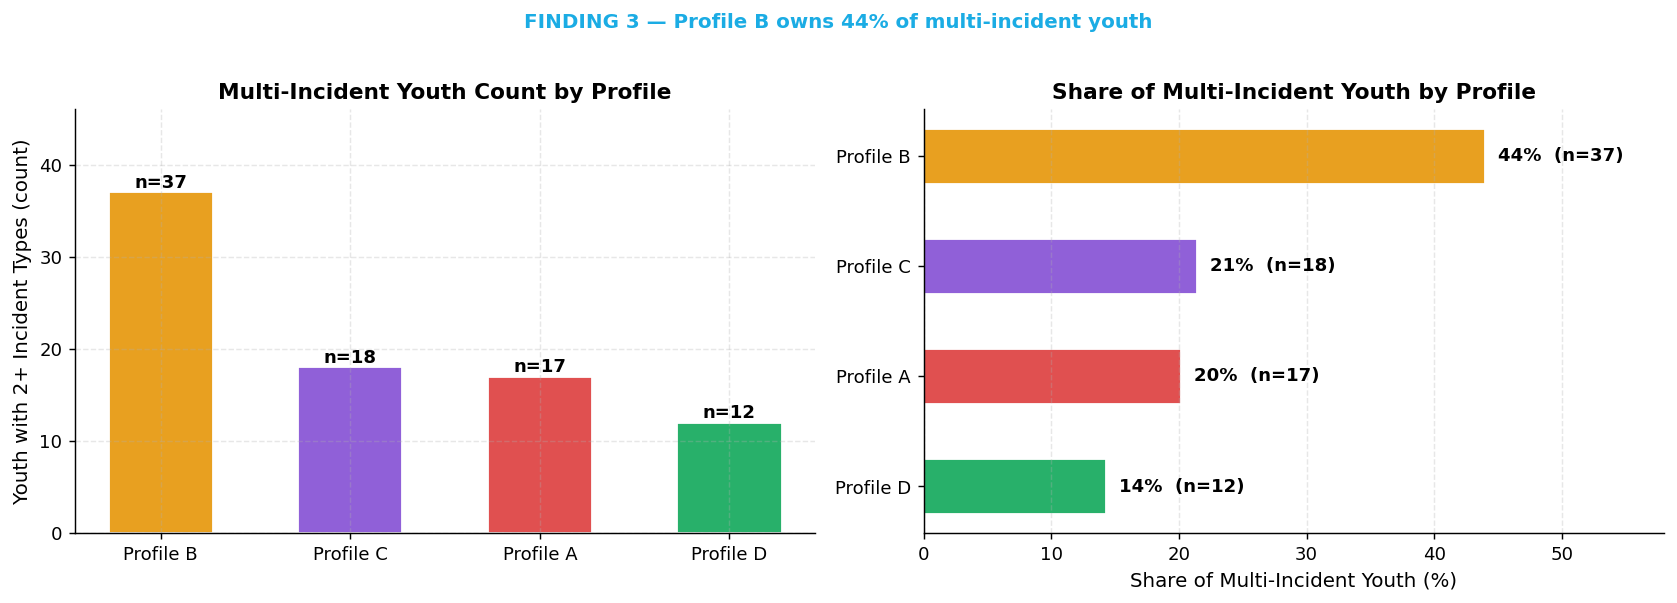

In [21]:
multi_sorted = multi_df.sort_values('pct_of_multi', ascending=False).reset_index()
print(multi_sorted.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: count bar
ax = axes[0]
bars = ax.bar(
    multi_sorted['Profile'], multi_sorted['n_multi'],
    color=[PROFILE_COLORS[p] for p in multi_sorted['Profile']],
    width=0.55, edgecolor='white'
)
ax.set_ylabel('Youth with 2+ Incident Types (count)')
ax.set_title('Multi-Incident Youth Count by Profile')
ax.set_ylim(0, 46)
for bar, (_, row) in zip(bars, multi_sorted.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'n={int(row["n_multi"])}', ha='center', fontsize=10, fontweight='bold')

# Right: share horizontal bar (sorted B->C->A->D)
ax = axes[1]
sort_order = multi_sorted.sort_values('pct_of_multi', ascending=True)
bars = ax.barh(
    sort_order['Profile'], sort_order['pct_of_multi'],
    color=[PROFILE_COLORS[p] for p in sort_order['Profile']],
    height=0.5, edgecolor='white'
)
ax.set_xlabel('Share of Multi-Incident Youth (%)')
ax.set_title('Share of Multi-Incident Youth by Profile')
ax.set_xlim(0, 58)
for bar, (_, row) in zip(bars, sort_order.iterrows()):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f"{row['pct_of_multi']:.0f}%  (n={int(row['n_multi'])})",
            va='center', fontsize=10, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', alpha=0)

plt.suptitle('FINDING 3 — Profile B owns 44% of multi-incident youth',
             fontsize=11, fontweight='bold', y=1.02, color=TEAL)
plt.tight_layout()
plt.savefig('fig_finding3.png', dpi=150, bbox_inches='tight')
plt.show()

### 10g · Incident Type Heatmap by Profile

                    Profile A  Profile B  Profile C  Profile D
Incident Type                                                 
Abuse / CPS Report      15.43      10.76      13.95       5.74
Suicide-Related          8.02       8.86       8.37       4.92
AWOL / Absence           7.41       5.38       7.91       2.19
Behavioral               4.94       5.70       5.12       2.19
Health / Medical         4.94       6.96       5.58       4.37
Self-Harm                3.09       2.53       1.40       0.55
Placement Changes        1.85       2.22       0.47       1.09
Police Involvement      10.49       6.65       4.19       0.82



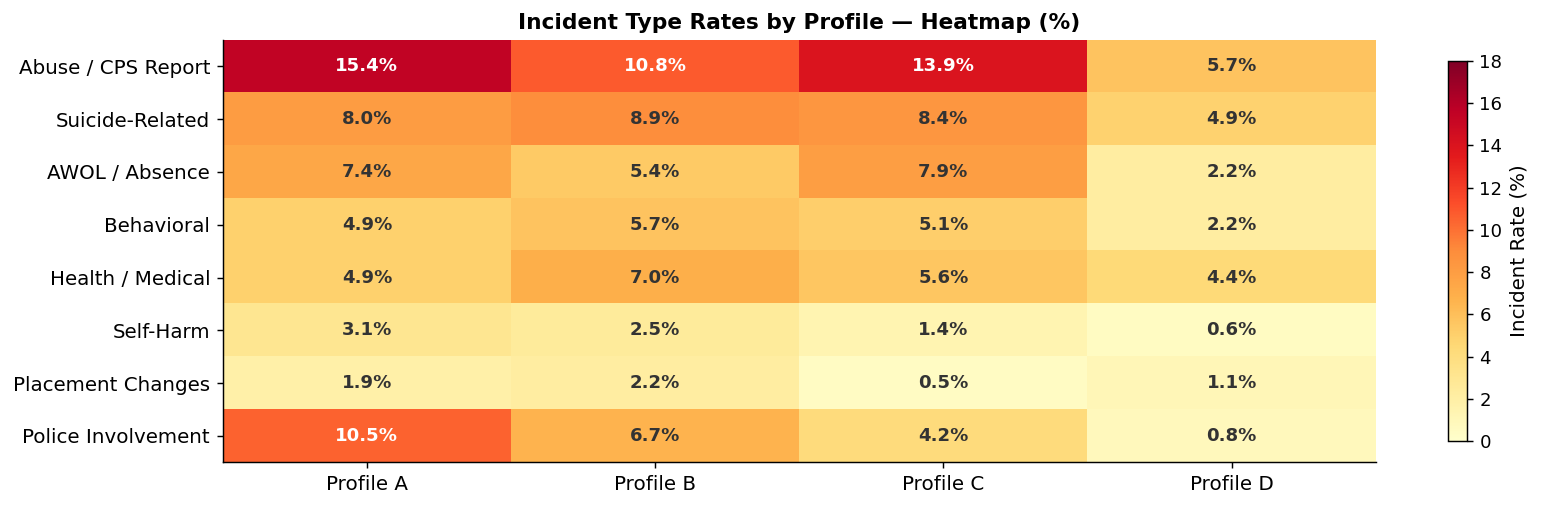

In [22]:
print(heat_df.round(2).to_string())
print()

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(heat_df[PROFILES].values, cmap='YlOrRd',
               aspect='auto', vmin=0, vmax=18)

ax.set_xticks(range(len(PROFILES)))
ax.set_xticklabels(PROFILES, fontsize=11)
ax.set_yticks(range(len(INCIDENT_LABELS)))
ax.set_yticklabels([INCIDENT_LABELS[c] for c in INCIDENT_COLS], fontsize=11)

for i in range(len(INCIDENT_COLS)):
    for j, p in enumerate(PROFILES):
        val = heat_df.loc[INCIDENT_LABELS[INCIDENT_COLS[i]], p]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if val > 10 else '#333')

plt.colorbar(im, ax=ax, shrink=0.9, label='Incident Rate (%)')
ax.set_title('Incident Type Rates by Profile — Heatmap (%)', fontweight='bold')
ax.grid(False)
plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11 — Validation Checks Against Dashboard Targets

Every metric shown in the dashboard HTML is listed here as a target value.
The notebook recomputes each one and flags any mismatch (tolerance: 0.01 pp).

> **Note on rounding:** Dashboard displays values rounded to 1 decimal place.
> Validation uses the full-precision computed values and rounds only for comparison.
> A tolerance of 0.05 percentage points is applied to account for display rounding.

In [23]:
TOLERANCE = 0.05   # percentage points

# ── Dashboard target values (from HTML data objects) ─────────────────────
TARGETS = {
    # Profile sizes
    'n_Profile_A':      162,
    'n_Profile_B':      316,
    'n_Profile_C':      215,
    'n_Profile_D':      366,

    # Any-incident rates (%)
    'inc_rate_A':       43.21,
    'inc_rate_B':       34.81,
    'inc_rate_C':       34.88,
    'inc_rate_D':       18.31,

    # Domain means
    'be_A': 1.5455, 'lf_A': 1.4036, 'rb_A': 1.0622,
    'be_B': 1.0397, 'lf_B': 0.7579, 'rb_B': 0.5050,
    'be_C': 1.0481, 'lf_C': 1.3174, 'rb_C': 0.3971,
    'be_D': 0.5304, 'lf_D': 0.5406, 'rb_D': 0.1432,

    # Interaction rates (%)
    'int_00':       25.24,
    'int_10':       36.16,
    'int_01':       27.27,
    'int_11':       60.71,
    'additive_pred':38.19,

    # Trajectory — Suicide Risk (A1–A5)
    'sr_A1': 1.0875, 'sr_A2': 0.9576, 'sr_A3': 0.9254, 'sr_A4': 0.7619, 'sr_A5': 0.5517,
    'sr_B1': 0.6134, 'sr_B2': 0.6148, 'sr_B3': 0.5238, 'sr_B4': 0.5982, 'sr_B5': 0.5312,
    'sr_C1': 0.4326, 'sr_C2': 0.4651, 'sr_C3': 0.5478, 'sr_C4': 0.5556, 'sr_C5': 0.5918,
    'sr_D1': 0.2210, 'sr_D2': 0.2431, 'sr_D3': 0.2808, 'sr_D4': 0.2286, 'sr_D5': 0.2667,

    # Multi-incident
    'multi_total':  84,
    'multi_pct_A':  20.2,
    'multi_pct_B':  44.0,
    'multi_pct_C':  21.4,
    'multi_pct_D':  14.3,

    # Heatmap — Police and Self-Harm (spot checks)
    'police_A': 10.49, 'police_B': 6.65, 'police_C': 4.19, 'police_D': 0.82,
    'sh_A':      3.09, 'sh_B':     2.53, 'sh_C':     1.40, 'sh_D':     0.55,
}

# ── Notebook-computed values ──────────────────────────────────────────────
COMPUTED = {}
# Sizes
for p in PROFILES:
    k = p.replace(' ','_')
    COMPUTED[f'n_{k}'] = int(df[df['profile']==p]['OptionsNumber'].count())
# Incident rates
for p in PROFILES:
    key = f'inc_rate_{p[-1]}'
    COMPUTED[key] = df[df['profile']==p]['any_incident'].mean() * 100
# Domain means
for p in PROFILES:
    k = p[-1]
    sub = df[df['profile']==p]
    COMPUTED[f'be_{k}'] = sub['be_mean'].mean()
    COMPUTED[f'lf_{k}'] = sub['lf_mean'].mean()
    COMPUTED[f'rb_{k}'] = sub['rb_mean'].mean()
# Interaction
COMPUTED['int_00']        = r00 * 100
COMPUTED['int_10']        = r10 * 100
COMPUTED['int_01']        = r01 * 100
COMPUTED['int_11']        = r11 * 100
COMPUTED['additive_pred'] = additive_pred * 100
# Trajectory
for p in PROFILES:
    k = p[-1]
    for n in range(1, MAX_N+1):
        sub = full[(full['profile']==p) & (full['assessment_n']==n)]['Suicide Risk'].dropna()
        COMPUTED[f'sr_{k}{n}'] = sub.mean() if len(sub) > 5 else np.nan
# Multi-incident
COMPUTED['multi_total'] = len(multi)
for p in PROFILES:
    COMPUTED[f'multi_pct_{p[-1]}'] = len(multi[multi['profile']==p]) / len(multi) * 100
# Heatmap spot checks
for p in PROFILES:
    k = p[-1]
    sub = df[df['profile']==p]
    COMPUTED[f'police_{k}'] = sub['Police_Involvement_event'].mean() * 100
    COMPUTED[f'sh_{k}']     = sub['Self_Harm_event'].mean() * 100

# ── Comparison ────────────────────────────────────────────────────────────
print(f'{"Metric":<22}  {"Target":>10}  {"Computed":>10}  {"Diff":>8}  Status')
print('-' * 68)
all_pass = True
for key, target in sorted(TARGETS.items()):
    computed = COMPUTED.get(key, np.nan)
    if isinstance(target, int):
        diff   = abs(computed - target)
        status = 'PASS' if diff == 0 else 'FAIL'
    else:
        diff   = abs(computed - target)
        status = 'PASS' if diff <= TOLERANCE else 'FAIL'
    if status == 'FAIL':
        all_pass = False
    flag = '' if status == 'PASS' else '  <-- MISMATCH'
    print(f'  {key:<22}  {target:>10.4f}  {computed:>10.4f}  {diff:>8.4f}  {status}{flag}')

print()
if all_pass:
    print('ALL CHECKS PASSED — notebook values match dashboard exactly.')
else:
    print('Some checks failed. Review MISMATCH rows above.')

Metric                      Target    Computed      Diff  Status
--------------------------------------------------------------------
  additive_pred              38.1900     38.1907    0.0007  PASS
  be_A                        1.5455      1.5455    0.0000  PASS
  be_B                        1.0397      1.0397    0.0000  PASS
  be_C                        1.0481      1.0481    0.0000  PASS
  be_D                        0.5304      0.5304    0.0000  PASS
  inc_rate_A                 43.2100     43.2099    0.0001  PASS
  inc_rate_B                 34.8100     34.8101    0.0001  PASS
  inc_rate_C                 34.8800     34.8837    0.0037  PASS
  inc_rate_D                 18.3100     18.3060    0.0040  PASS
  int_00                     25.2400     25.2427    0.0027  PASS
  int_01                     27.2700     27.2727    0.0027  PASS
  int_10                     36.1600     36.1607    0.0007  PASS
  int_11                     60.7100     60.7143    0.0043  PASS
  lf_A               